In [1]:
import torch
import torch.nn as nn

# Реализация конкретной модели VGG — "в лоб"

In [2]:
class VGG11(nn.Module):
    def __init__(self, num_classes=1000, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, (3, 3), padding=1),
            nn.ReLU(True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, (3, 3), padding=1),
            nn.ReLU(True),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, (3, 3), padding=1),
            nn.ReLU(True),
            nn.Conv2d(256, 256, (3, 3), padding=1),
            nn.ReLU(True),
            nn.MaxPool2d(2),
            nn.Conv2d(256, 512, (3, 3), padding=1),
            nn.ReLU(True),
            nn.Conv2d(512, 512, (3, 3), padding=1),
            nn.ReLU(True),
            nn.MaxPool2d(2),
            nn.Conv2d(512, 512, (3, 3), padding=1),
            nn.ReLU(True),
            nn.Conv2d(512, 512, (3, 3), padding=1),
            nn.ReLU(True),
            nn.MaxPool2d(2)
        )
        # self.avgpool = nn.AdaptiveAvgPool2d((7, 7))
        self.flatten = nn.Flatten()
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(True),
            nn.Dropout(p=dropout),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(p=dropout),
            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        # x = self.avgpool(x)
        x = self.flatten(x)
        out = self.classifier(x)
        return out

In [3]:
model = VGG11()

input = torch.rand([1, 3, 224, 224], dtype=torch.float32)
output = model(input)
print(output.shape)

torch.Size([1, 1000])


# Реализация общего класса модели VGG

In [4]:
cfgs = {
    "vgg_11": [64, "M", 128, "M", 256, 256, "M", 512, 512, "M", 512, 512, "M"],
    "vgg_13": [64, 64, "M", 128, 128, "M", 256, 256, "M", 512, 512, "M", 512, 512, "M"],
    "vgg_16": [64, 64, "M", 128, 128, "M", 256, 256, 256, "M", 512, 512, 512, "M", 512, 512, 512, "M"],
    "vgg_19": [64, 64, "M", 128, 128, "M", 256, 256, 256, 256, "M", 512, 512, 512, 512, "M", 512, 512, 512, 512, "M"],
}

In [5]:
class VGG(nn.Module):
    _cfgs = {
        "vgg_11": [64, "M", 128, "M", 256, 256, "M", 512, 512, "M", 512, 512, "M"],
        "vgg_13": [64, 64, "M", 128, 128, "M", 256, 256, "M", 512, 512, "M", 512, 512, "M"],
        "vgg_16": [64, 64, "M", 128, 128, "M", 256, 256, 256, "M", 512, 512, 512, "M", 512, 512, 512, "M"],
        "vgg_19": [64, 64, "M", 128, 128, "M", 256, 256, 256, 256, "M", 512, 512, 512, 512, "M", 512, 512, 512, 512, "M"],
    }

    def __init__(self, name, num_classes=1000, dropout=0.5):
        super().__init__()
        self.cfg = self._cfgs[name]

        self.features = self.make_layers(self.cfg)
        # self.avgpool = nn.AdaptiveAvgPool2d((7, 7))
        self.flatten = nn.Flatten()
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(True),
            nn.Dropout(p=dropout),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(p=dropout),
            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        # x = self.avgpool(x)
        x = self.flatten(x)
        out = self.classifier(x)
        return out

    def make_layers(self, cfg):
        layers = []
        in_channels = 3
        for value in cfg:
            if value == "M":
                layers += [nn.MaxPool2d(2)]
            else:
                conv2d = nn.Conv2d(in_channels, value, (3, 3), padding=1)
                layers += [conv2d, nn.ReLU(True)]
                in_channels = value
        return nn.Sequential(*layers)

In [6]:
model = VGG("vgg_19")
model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [7]:
input = torch.rand([1, 3, 224, 224], dtype=torch.float32)
pred = model(input)
print(pred.shape)

torch.Size([1, 1000])


# Готовая архитектура VGG в torchvision

In [8]:
import torchvision
from torchvision import models
import torchvision.transforms as v1
from torchvision.transforms import v2
import matplotlib.pyplot as plt
from PIL import Image

plt.style.use('dark_background')

In [11]:
vgg11 = models.vgg11()

In [12]:
vgg13 = models.vgg13(pretrained=True) # Устаревший метод

D:\Anaconda3\envs\machine_learning\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
D:\Anaconda3\envs\machine_learning\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG13_Weights.IMAGENET1K_V1`. You can also use `weights=VGG13_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg13-19584684.pth" to C:\Users\SashaCurry/.cache\torch\hub\checkpoints\vgg13-19584684.pth


100%|██████████| 508M/508M [00:47<00:00, 11.1MB/s] 


In [13]:
vgg19 = models.vgg19(weights='DEFAULT')
# vgg19 = models.vgg19(weights='IMAGENET1K_V1')

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to C:\Users\SashaCurry/.cache\torch\hub\checkpoints\vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:51<00:00, 11.1MB/s] 


In [14]:
input = torch.rand([1, 3, 224, 224], dtype=torch.float32)

output = vgg19(input)
print(output.shape)

torch.Size([1, 1000])


## Обученные веса всех моделей

In [15]:
weights_vgg11 = models.VGG11_Weights.IMAGENET1K_V1
weights_vgg13 = models.VGG13_Weights.DEFAULT
weights_vgg16 = models.VGG16_Weights.DEFAULT
weights_vgg19 = models.VGG19_Weights.DEFAULT

In [16]:
vgg16 = models.vgg16(weights=weights_vgg16)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\SashaCurry/.cache\torch\hub\checkpoints\vgg16-397923af.pth


100%|██████████| 528M/528M [00:49<00:00, 11.2MB/s] 


In [17]:
# url для скаченных весов модели
url = weights_vgg19.url
url

'https://download.pytorch.org/models/vgg19-dcbb9e9d.pth'

In [18]:
# Трансформации, которые применялись к изображениям при тренировке
transform_default = weights_vgg19.transforms()
transform_default

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [19]:
# Список с именами классов
class_names = weights_vgg19.meta['categories']
print(type(class_names))
print(len(class_names))
print(class_names)

<class 'list'>
1000
['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich', 'brambling', 'goldfinch', 'house finch', 'junco', 'indigo bunting', 'robin', 'bulbul', 'jay', 'magpie', 'chickadee', 'water ouzel', 'kite', 'bald eagle', 'vulture', 'great grey owl', 'European fire salamander', 'common newt', 'eft', 'spotted salamander', 'axolotl', 'bullfrog', 'tree frog', 'tailed frog', 'loggerhead', 'leatherback turtle', 'mud turtle', 'terrapin', 'box turtle', 'banded gecko', 'common iguana', 'American chameleon', 'whiptail', 'agama', 'frilled lizard', 'alligator lizard', 'Gila monster', 'green lizard', 'African chameleon', 'Komodo dragon', 'African crocodile', 'American alligator', 'triceratops', 'thunder snake', 'ringneck snake', 'hognose snake', 'green snake', 'king snake', 'garter snake', 'water snake', 'vine snake', 'night snake', 'boa constrictor', 'rock python', 'Indian cobra', 'green mamba', 'sea snake', 'horned vip

## Предсказания обученной модели

In [21]:
img = Image.open('/Users/SashaCurry/PyCharmMiscProject/content/Maybe-Baby.jpg')

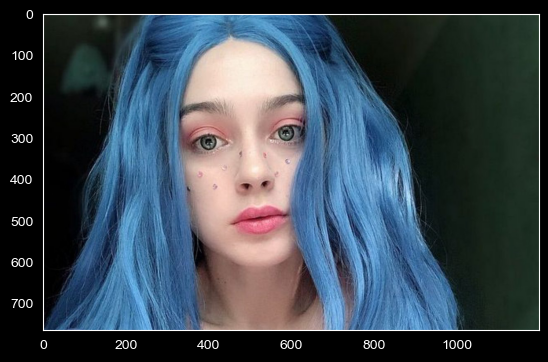

In [23]:
plt.grid(False)
plt.imshow(img)

In [25]:
# Стандартные преобразования изображений (до размеров 224 на 224 пикселя)
transform_default = weights_vgg19.transforms()

In [26]:
# Преобразования изображений на основе модуля V1.
size = 224

transform_v1 = v1.Compose([
    v1.Resize(256),
    v1.CenterCrop(size),
    v1.ToTensor(),
    v1.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

In [27]:
# Преобразования изображений на основе модуля V2.
size = 224

transform_v2 = v2.Compose([
    v2.ToImage(),
    v2.Resize(256),
    v2.CenterCrop(size),
    v2.ToDtype(dtype=torch.float32, scale=True),
    v2.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

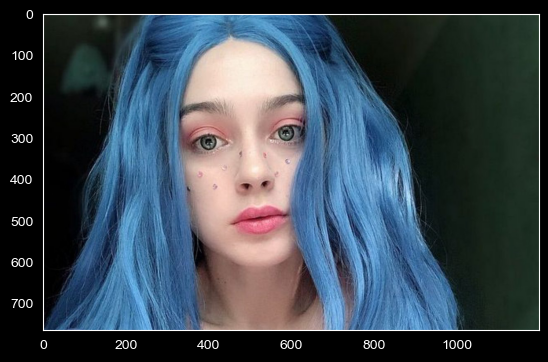

transform_default:
    wig => 0.96870
    hair spray => 0.01051
    fur coat => 0.00179
    cloak => 0.00175
    lipstick => 0.00172
    wool => 0.00156

transform_v1:
    wig => 0.96870
    hair spray => 0.01051
    fur coat => 0.00179
    cloak => 0.00175
    lipstick => 0.00172
    wool => 0.00156

transform_v2:
    wig => 0.96889
    hair spray => 0.01046
    fur coat => 0.00178
    cloak => 0.00173
    lipstick => 0.00171
    wool => 0.00156



In [32]:
transforms = {
    'transform_default': transform_default,
    'transform_v1': transform_v1,
    'transform_v2': transform_v2
}

plt.imshow(img)
plt.grid(False)
plt.show()

vgg19.eval()
for name, transform in transforms.items():
    print(f'{name}:')
    img_in = transform(img).unsqueeze(dim=0)     # img => transform => (3, 224, 224) => unsqueeze => (1, 3, 224, 224) => img_in
    pred = vgg19(img_in).squeeze()   # (1, 1000) => (1000)

    sorted, indices = pred.softmax(dim=0).sort(descending=True)
    for i, (s, ind) in enumerate(zip(sorted, indices)):
        print(f"    {class_names[ind]} => {s:.5f}")
        if i//5:
            break
    print("================", end='\n\n')